# Khai báo Thư viện & Cấu hình

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import SegformerImageProcessor
import timm
import numpy as np
import matplotlib.pyplot as plt
import warnings

import random
from tqdm.auto import tqdm
import seaborn as sns

warnings.filterwarnings("ignore") 

print(" ĐÃ NẠP THƯ VIỆN THÀNH CÔNG ")

 ĐÃ NẠP THƯ VIỆN THÀNH CÔNG 


In [2]:
# --- CẤU HÌNH SIÊU THAM SỐ ---
CFG = {
    "num_classes": 104, 
    "image_size": 256,    
    "batch_size": 16,     
    "epochs": 50,     
    "learning_rate": 6e-4, 
    "patience": 3,        
    "lr_patience": 1,     
    "lr_factor": 0.5,    
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}
print(f" Đang sử dụng thiết bị: {CFG['device']}")

 Đang sử dụng thiết bị: cuda


# Kiến trúc Model & Hàm mIoU

In [3]:
# --- KHỐI GIẢI MÃ FPN & FCM ---
class FPNDecoder(nn.Module):
    def __init__(self, encoder_channels, feature_dim=256):
        super().__init__()
        self.lateral4 = nn.Conv2d(encoder_channels[3], feature_dim, 1)
        self.lateral3 = nn.Conv2d(encoder_channels[2], feature_dim, 1)
        self.lateral2 = nn.Conv2d(encoder_channels[1], feature_dim, 1)
        self.lateral1 = nn.Conv2d(encoder_channels[0], feature_dim, 1)
        self.smooth = nn.Conv2d(feature_dim, feature_dim, 3, padding=1)
        
    def forward(self, features):
        s1, s2, s3, s4 = features
        p4 = self.lateral4(s4)
        p3 = self.lateral3(s3) + F.interpolate(p4, size=s3.shape[2:], mode='bilinear', align_corners=False)
        p2 = self.lateral2(s2) + F.interpolate(p3, size=s2.shape[2:], mode='bilinear', align_corners=False)
        p1 = self.lateral1(s1) + F.interpolate(p2, size=s1.shape[2:], mode='bilinear', align_corners=False)
        return self.smooth(p1)

class FoodCoOccurrenceModule(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.co_occurrence_matrix = nn.Parameter(torch.ones(num_classes, num_classes) / num_classes)
        self.mapping = nn.Sequential(nn.Conv2d(num_classes, num_classes, 1), nn.ReLU(), nn.Conv2d(num_classes, num_classes, 1))
        
    def forward(self, logits):
        b, c, h, w = logits.shape
        adj = F.softmax(self.co_occurrence_matrix, dim=-1)
        flat_logits = logits.view(b, c, h * w).permute(0, 2, 1)
        co_features = torch.matmul(flat_logits, adj).permute(0, 2, 1).view(b, c, h, w)
        return logits + self.mapping(co_features)

# --- KIẾN TRÚC MẠNG CHÍNH HDF ---
class HDFModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = timm.create_model('swinv2_tiny_window16_256', pretrained=True, features_only=True, dynamic_img_size=True)
        self.decoder = FPNDecoder(self.backbone.feature_info.channels(), feature_dim=256)
        self.cls_head = nn.Conv2d(256, num_classes, kernel_size=1)
        self.fcm = FoodCoOccurrenceModule(num_classes)
        
    def forward(self, x):
        features = self.backbone(x)
        # Fix xoay trục ma trận từ NHWC sang NCHW
        features = [f.permute(0, 3, 1, 2).contiguous() for f in features]
        fpn_out = self.decoder(features)
        logits_upsampled = F.interpolate(self.cls_head(fpn_out), size=x.shape[2:], mode='bilinear', align_corners=False)
        return self.fcm(logits_upsampled)

# --- HÀM TÍNH ĐỘ ĐO mIoU ---
def compute_iou(preds, labels, num_classes, ignore_index=255):
    valid_mask = (labels != ignore_index)
    preds = preds[valid_mask]
    labels = labels[valid_mask]
    
    inter = torch.bincount(labels[preds == labels], minlength=num_classes)
    pred_counts = torch.bincount(preds, minlength=num_classes)
    label_counts = torch.bincount(labels, minlength=num_classes)
    union = pred_counts + label_counts - inter
    return inter, union

print(" Đã khởi tạo xong các Class kiến trúc mạng!")

 Đã khởi tạo xong các Class kiến trúc mạng!


# Tải & Xử lý Dữ Liệu

In [4]:
# 1. Tải dataset gốc 
print("Đang tải dữ liệu FoodSeg103...")
dataset = load_dataset("EduardoPacheco/FoodSeg103")

# 2. Tạo bản chỉ để EDA 
raw_train = dataset['train'] 
raw_validation = dataset['validation']

# 3. Tạo bản 'processed' chuyên dùng cho Training 
processor = SegformerImageProcessor(do_resize=True, size={"height": 256, "width": 256}, do_normalize=True, ignore_index=255)

def transforms(example_batch):
    return processor([x for x in example_batch['image']], [x for x in example_batch['label']], return_tensors="pt")

# Áp dụng transform CHỈ CHO BẢN ĐỂ TRAIN
train_dataset_processed = dataset["train"].with_transform(transforms)
val_dataset_processed = dataset["validation"].with_transform(transforms)

# 4. Khởi tạo Dataloader
train_dataloader = DataLoader(train_dataset_processed, batch_size=16, shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_dataset_processed, batch_size=16, shuffle=False)

print(" Đã tách biệt bản EDA và bản Train thành công!")

Đang tải dữ liệu FoodSeg103...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/351M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/357M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/431M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4983 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2135 [00:00<?, ? examples/s]

 Đã tách biệt bản EDA và bản Train thành công!


# Khám phá Tổng quan Data

In [5]:
# Dataset raw_train hiện tại đã là bản gốc chưa transform
# nên không cần with_transform(None)

print(" BÁO CÁO TỔNG QUAN DỮ LIỆU FOODSEG103 ")
print("-" * 50)

print(f" - Số lượng ảnh tập Train: {len(raw_train)} ảnh")
print(f" - Số lượng ảnh tập Validation: {len(raw_validation)} ảnh")

print("\n Kích thước 5 ảnh đầu tiên trong tập Train:")

for i in range(5):
    img = raw_train[i]['image']
    print(f"   - Ảnh {i+1}: Rộng {img.width}px x Cao {img.height}px")

try:
    labels = raw_train.features['label'].feature.names

    print(f"\n Tổng số nhãn: {len(labels)} (Bao gồm cả Background/Ignore)")
    print(" Top 10 nhãn đầu tiên:")
    print(" | ".join(labels[:10]))

except Exception:
    print("\n Dataset dùng mã ID số nguyên cho nhãn (0 đến 103).")

 BÁO CÁO TỔNG QUAN DỮ LIỆU FOODSEG103 
--------------------------------------------------
 - Số lượng ảnh tập Train: 4983 ảnh
 - Số lượng ảnh tập Validation: 2135 ảnh

 Kích thước 5 ảnh đầu tiên trong tập Train:
   - Ảnh 1: Rộng 512px x Cao 384px
   - Ảnh 2: Rộng 512px x Cao 384px
   - Ảnh 3: Rộng 512px x Cao 384px
   - Ảnh 4: Rộng 512px x Cao 384px
   - Ảnh 5: Rộng 512px x Cao 384px

 Dataset dùng mã ID số nguyên cho nhãn (0 đến 103).


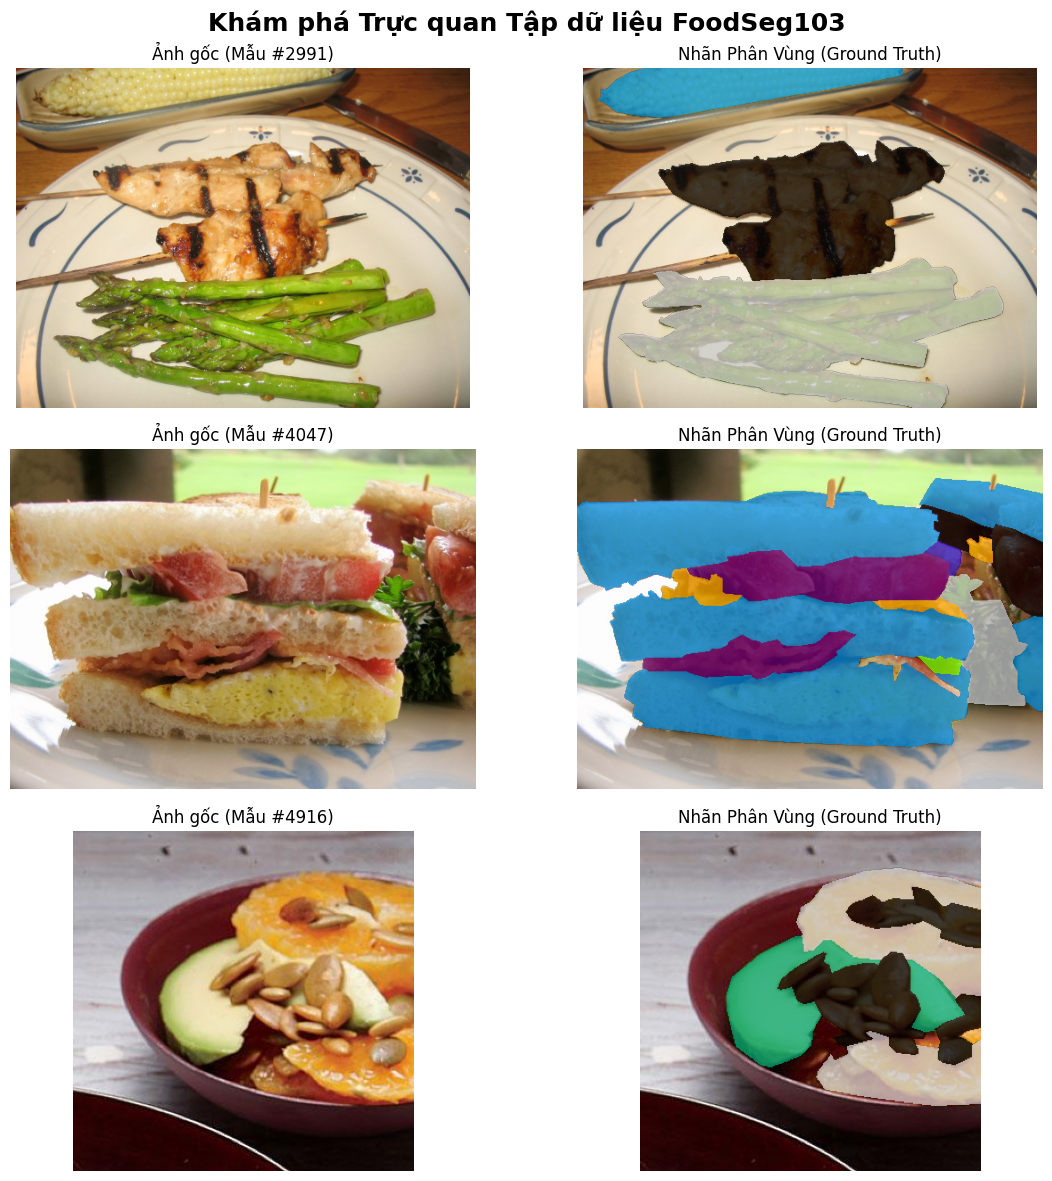

In [6]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Không cần with_transform(None)
raw_train = dataset['train']

sample_indices = random.sample(range(len(raw_train)), 3)
samples = [raw_train[i] for i in sample_indices]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle(
    "Khám phá Trực quan Tập dữ liệu FoodSeg103",
    fontsize=18,
    fontweight='bold',
    y=0.98
)

for i, sample in enumerate(samples):

    img = sample['image']
    mask = sample['label']

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(
        f"Ảnh gốc (Mẫu #{sample_indices[i]})",
        fontsize=12
    )
    axes[i, 0].axis('off')

    axes[i, 1].imshow(img)

    mask_array = np.array(mask)

    masked_data = np.ma.masked_where(
        (mask_array == 0) | (mask_array == 255),
        mask_array
    )

    axes[i, 1].imshow(
        masked_data,
        cmap='nipy_spectral',
        alpha=0.75
    )

    axes[i, 1].set_title(
        "Nhãn Phân Vùng (Ground Truth)",
        fontsize=12
    )

    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

 Đang quét 500 ảnh ngẫu nhiên để phân tích dữ liệu...


Đang phân tích:   0%|          | 0/500 [00:00<?, ?it/s]

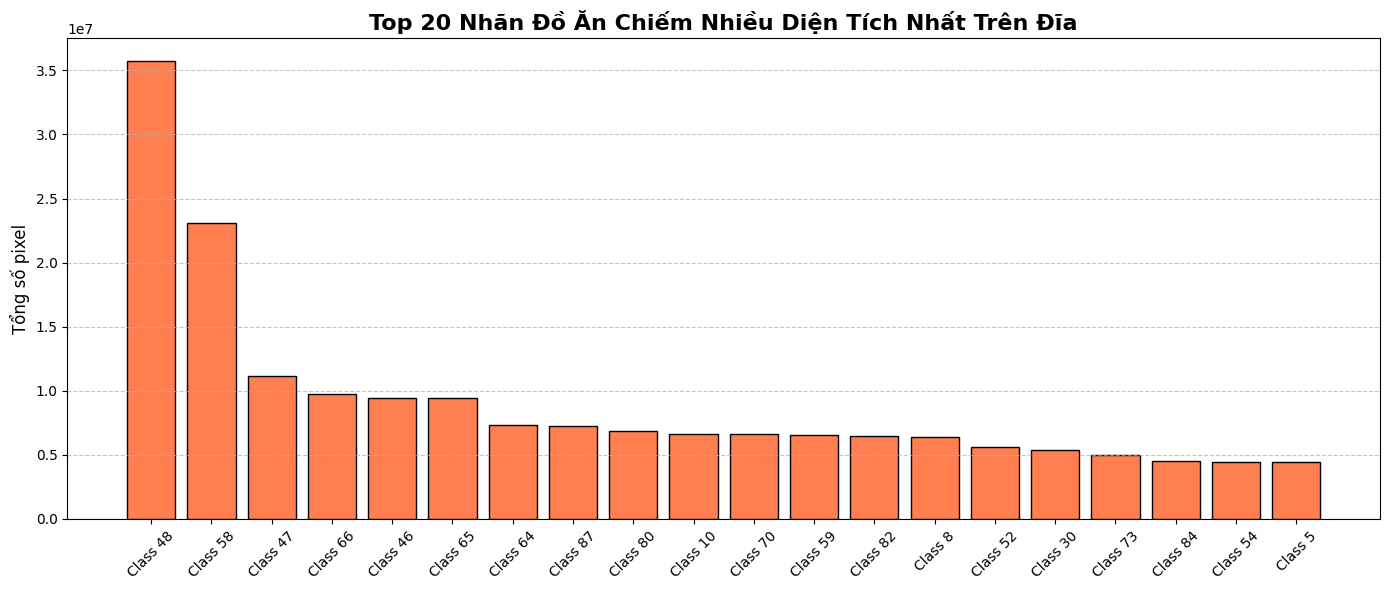

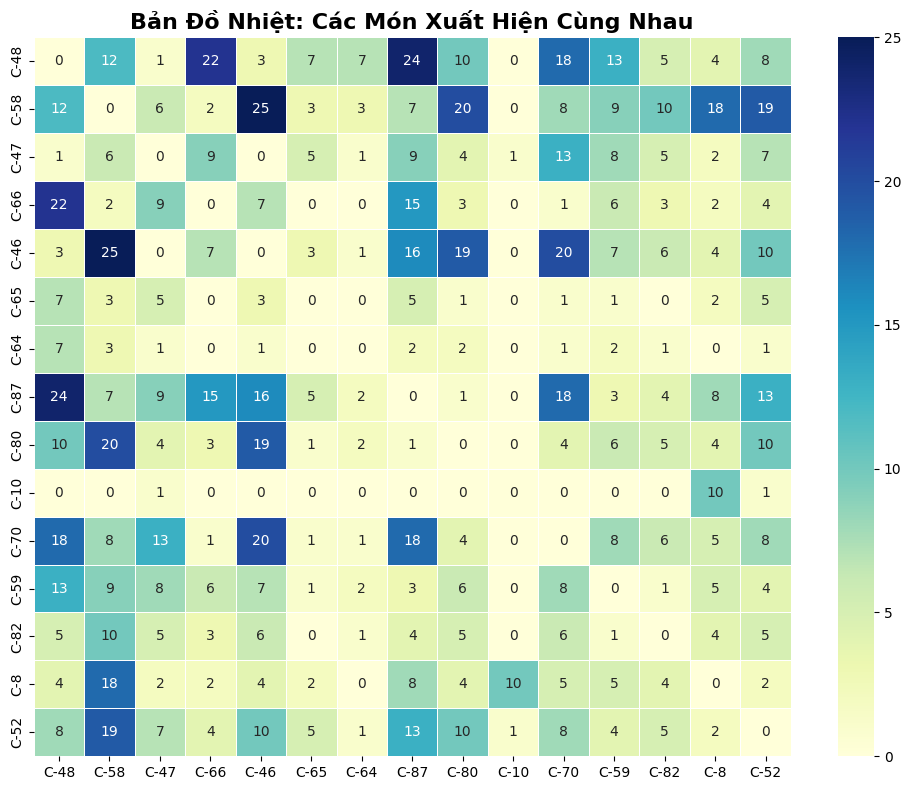

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Không cần with_transform(None)
raw_train = dataset['train']

print(" Đang quét 500 ảnh ngẫu nhiên để phân tích dữ liệu...")

sample_size = 500
indices = np.random.choice(
    len(raw_train),
    sample_size,
    replace=False
)

class_counts = np.zeros(104)
co_matrix = np.zeros((104, 104))

for idx in tqdm(indices, desc="Đang phân tích"):

    mask = np.array(raw_train[idx]['label'])

    # 1. Đếm pixel (Class Imbalance)
    valid_pixels = mask[
        (mask != 0) & (mask != 255)
    ]

    counts = np.bincount(
        valid_pixels,
        minlength=104
    )

    class_counts += counts

    # 2. Xây dựng ma trận đồng xuất hiện
    unique_classes = np.unique(mask)

    unique_classes = unique_classes[
        (unique_classes != 0) &
        (unique_classes != 255)
    ]

    for i in unique_classes:
        for j in unique_classes:
            if i != j:
                co_matrix[i, j] += 1

# ===== BIỂU ĐỒ 1 =====
top_20_idx = np.argsort(class_counts)[-20:][::-1]
top_20_counts = class_counts[top_20_idx]

plt.figure(figsize=(14, 6))

plt.bar(
    range(20),
    top_20_counts,
    color='coral',
    edgecolor='black'
)

plt.xticks(
    range(20),
    [f"Class {i}" for i in top_20_idx],
    rotation=45,
    fontsize=10
)

plt.title(
    "Top 20 Nhãn Đồ Ăn Chiếm Nhiều Diện Tích Nhất Trên Đĩa",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel("Tổng số pixel", fontsize=12)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()
plt.show()

# ===== HEATMAP =====
top_15_idx = np.argsort(class_counts)[-15:][::-1]

sub_matrix = co_matrix[
    np.ix_(top_15_idx, top_15_idx)
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    sub_matrix,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    xticklabels=[f"C-{i}" for i in top_15_idx],
    yticklabels=[f"C-{i}" for i in top_15_idx],
    linewidths=.5
)

plt.title(
    "Bản Đồ Nhiệt: Các Món Xuất Hiện Cùng Nhau",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Đưa mô hình vào GPU & Khởi tạo Tối ưu hóa

In [8]:
# Đưa model lên GPU
model = HDFModel(num_classes=CFG["num_classes"]).to(CFG["device"])

if torch.cuda.device_count() > 1:
    print(f" Kích hoạt DataParallel: Đang chạy đa luồng trên {torch.cuda.device_count()} GPU!")
    model = nn.DataParallel(model)

# Khai báo Loss và Optimizer
criterion = nn.CrossEntropyLoss(ignore_index=255)
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["learning_rate"])

# Khai báo Scheduler điều chỉnh tốc độ học
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=CFG["lr_factor"], patience=CFG["lr_patience"]
)

# Các biến theo dõi Early Stopping
best_miou = 0.0 
patience_counter = 0 
save_path = "hdf_swin_best_model.pth" 

print(" Đã nạp  xong! (GPU T4)!")

model.safetensors:   0%|          | 0.00/119M [00:00<?, ?B/s]

 Kích hoạt DataParallel: Đang chạy đa luồng trên 2 GPU!
 Đã nạp  xong! (GPU T4)!


# Vòng lặp Huấn luyện

In [9]:
for epoch in range(CFG["epochs"]):
    current_lr = optimizer.param_groups[0]['lr']
    
    # 1. Quá trình Train
    model.train()
    running_loss = 0.0
    print(f"\n[Epoch {epoch+1}/{CFG['epochs']}] Đang huấn luyện... (LR: {current_lr:.6f})")
    for batch in train_dataloader:
        images, labels = batch["pixel_values"].to(CFG["device"]), batch["labels"].to(CFG["device"])
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    train_loss = running_loss / len(train_dataloader)
    
    # 2. Quá trình Evaluation
    model.eval()
    total_inter = torch.zeros(CFG["num_classes"]).to(CFG["device"])
    total_union = torch.zeros(CFG["num_classes"]).to(CFG["device"])
    
    with torch.no_grad():
        for batch in val_dataloader:
            images, labels = batch["pixel_values"].to(CFG["device"]), batch["labels"].to(CFG["device"])
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            
            inter, union = compute_iou(preds, labels, CFG["num_classes"])
            total_inter += inter
            total_union += union
    
    valid_classes = total_union > 0
    ious = total_inter[valid_classes] / (total_union[valid_classes] + 1e-6)
    current_miou = ious.mean().item() * 100
    
    print(f"-> Hoàn thành Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Test mIoU: {current_miou:.2f}%")

    # 3. Cập nhật Scheduler và Early Stopping
    scheduler.step(current_miou)

    if current_miou > best_miou:
        best_miou = current_miou
        torch.save(model.state_dict(), save_path)
        print(f"🌟 Đỉnh mới! Đã lưu model xịn nhất (mIoU: {best_miou:.2f}%)")
        patience_counter = 0 
    else:
        patience_counter += 1
        print(f"⚠️ Điểm không cải thiện. Mức cảnh báo: {patience_counter}/{CFG['patience']}")

    if patience_counter >= CFG["patience"]:
        print(f"🛑 KÍCH HOẠT DỪNG SỚM (EARLY STOPPING)!")
        break

print(f"\n QUÁ TRÌNH HOÀN TẤT! Model tốt nhất đạt mIoU {best_miou:.2f}% đã nằm trong thư mục Output của Kaggle.")


[Epoch 1/50] Đang huấn luyện... (LR: 0.000600)
-> Hoàn thành Epoch 1 | Train Loss: 1.6821 | Test mIoU: 15.84%
🌟 Đỉnh mới! Đã lưu model xịn nhất (mIoU: 15.84%)

[Epoch 2/50] Đang huấn luyện... (LR: 0.000600)
-> Hoàn thành Epoch 2 | Train Loss: 1.0808 | Test mIoU: 20.43%
🌟 Đỉnh mới! Đã lưu model xịn nhất (mIoU: 20.43%)

[Epoch 3/50] Đang huấn luyện... (LR: 0.000600)
-> Hoàn thành Epoch 3 | Train Loss: 0.8949 | Test mIoU: 19.06%
⚠️ Điểm không cải thiện. Mức cảnh báo: 1/3

[Epoch 4/50] Đang huấn luyện... (LR: 0.000600)
-> Hoàn thành Epoch 4 | Train Loss: 0.7990 | Test mIoU: 22.90%
🌟 Đỉnh mới! Đã lưu model xịn nhất (mIoU: 22.90%)

[Epoch 5/50] Đang huấn luyện... (LR: 0.000600)
-> Hoàn thành Epoch 5 | Train Loss: 0.7046 | Test mIoU: 22.17%
⚠️ Điểm không cải thiện. Mức cảnh báo: 1/3

[Epoch 6/50] Đang huấn luyện... (LR: 0.000600)
-> Hoàn thành Epoch 6 | Train Loss: 0.6511 | Test mIoU: 23.12%
🌟 Đỉnh mới! Đã lưu model xịn nhất (mIoU: 23.12%)

[Epoch 7/50] Đang huấn luyện... (LR: 0.000600)
-> H

# Đánh Giá Tổng Quát

In [10]:
import torch
from tqdm.auto import tqdm

print(" Đang nạp lại model tốt nhất từ file .pth...")

# 1. Khởi tạo lại mô hình trống
best_model = HDFModel(num_classes=CFG["num_classes"]).to(CFG["device"])

# 2. Tải trọng số 
state_dict = torch.load("hdf_swin_best_model.pth", map_location=CFG["device"])
clean_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
best_model.load_state_dict(clean_state_dict)

best_model.eval()

# Biến tích lũy số liệu cho cả 3 độ đo (mIoU, mAcc, aAcc)
total_inter = torch.zeros(CFG["num_classes"]).to(CFG["device"])
total_union = torch.zeros(CFG["num_classes"]).to(CFG["device"])
total_label_counts = torch.zeros(CFG["num_classes"]).to(CFG["device"]) # Cần thêm cái này để tính mAcc
total_correct_pixels = 0
total_valid_pixels = 0

print(" Đang chấm điểm trên toàn bộ tập Validation...")
with torch.no_grad():
    for batch in tqdm(val_dataloader, desc="Scoring"):
        images, labels = batch["pixel_values"].to(CFG["device"]), batch["labels"].to(CFG["device"])
        outputs = best_model(images)
        preds = torch.argmax(outputs, dim=1)
        
        # Loại bỏ viền đen/nền không xác định 
        valid_mask = (labels != 255)
        valid_preds = preds[valid_mask].long()
        valid_labels = labels[valid_mask].long()
        
        # Đếm số lượng điểm ảnh (Bincounts)
        inter = torch.bincount(valid_labels[valid_preds == valid_labels], minlength=CFG["num_classes"])
        pred_counts = torch.bincount(valid_preds, minlength=CFG["num_classes"])
        label_counts = torch.bincount(valid_labels, minlength=CFG["num_classes"])
        union = pred_counts + label_counts - inter
        
        # Tích lũy cho mIoU và mAcc
        total_inter += inter
        total_union += union
        total_label_counts += label_counts
        
        # Tích lũy cho aAcc
        total_correct_pixels += (valid_preds == valid_labels).sum().item()
        total_valid_pixels += valid_mask.sum().item()

# --- TÍNH TOÁN 3 ĐỘ ĐO CHUẨN KHOA HỌC ---

# 1. Tính mIoU
valid_iou = total_union > 0
ious = total_inter[valid_iou] / (total_union[valid_iou] + 1e-6)
final_miou = ious.mean().item() * 100

# 2. Tính mAcc (Mean Class Accuracy = True Positives / (True Positives + False Negatives))
valid_acc = total_label_counts > 0
class_accs = total_inter[valid_acc] / (total_label_counts[valid_acc] + 1e-6)
final_macc = class_accs.mean().item() * 100

# 3. Tính aAcc (Overall Pixel Accuracy)
pixel_acc = (total_correct_pixels / total_valid_pixels) * 100

print("\n" + "="*45)
print(" KẾT QUẢ ĐÁNH GIÁ: ")
print("="*45)
print(f" 1. mIoU (Độ khớp vùng trung bình): {final_miou:.2f}%")
print(f" 2. mAcc (Độ chính xác từng món):   {final_macc:.2f}%")
print(f" 3. aAcc (Độ chính xác điểm ảnh):   {pixel_acc:.2f}%")
print("="*45)

 Đang nạp lại model tốt nhất từ file .pth...
 Đang chấm điểm trên toàn bộ tập Validation...


Scoring:   0%|          | 0/134 [00:00<?, ?it/s]


 KẾT QUẢ ĐÁNH GIÁ: 
 1. mIoU (Độ khớp vùng trung bình): 33.91%
 2. mAcc (Độ chính xác từng món):   43.38%
 3. aAcc (Độ chính xác điểm ảnh):   77.94%


 Đang vẽ ảnh so sánh Trực quan để xuất báo cáo Slide...


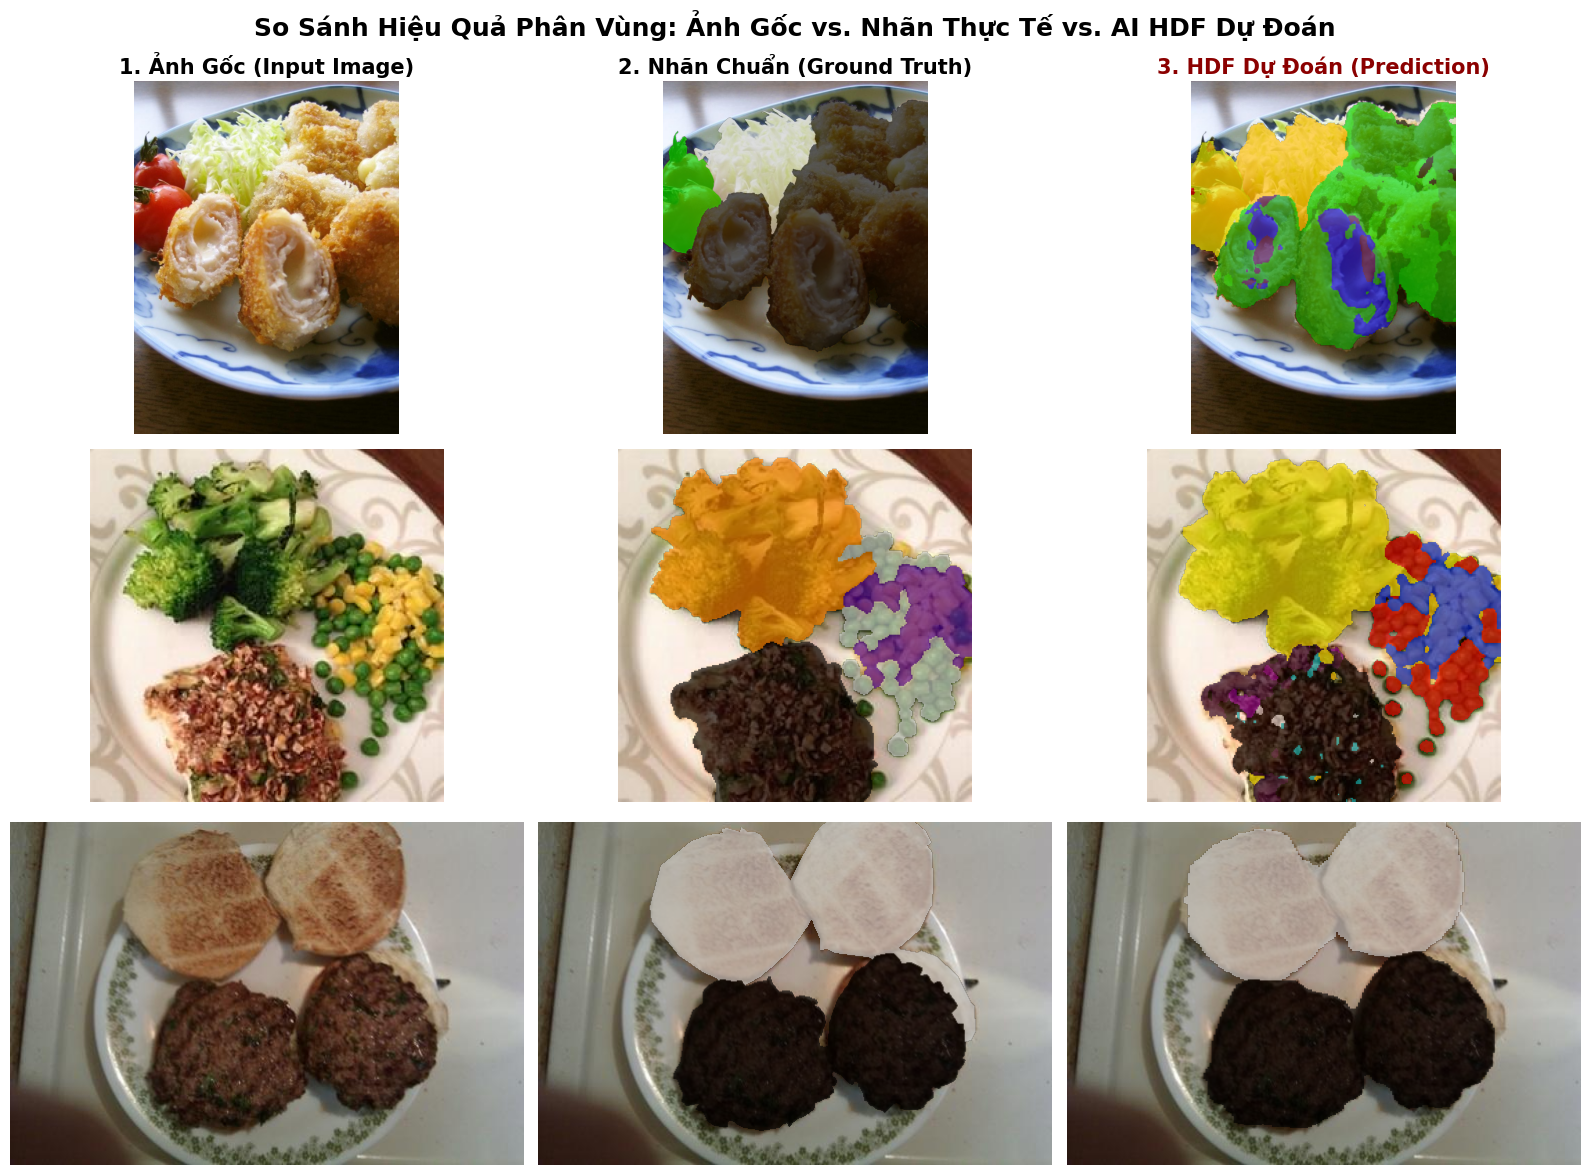

In [11]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
import cv2  

print(" Đang vẽ ảnh so sánh Trực quan để xuất báo cáo Slide...")

sample_indices = random.sample(range(len(dataset["validation"])), 3)
samples = [dataset["validation"][i] for i in sample_indices]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("So Sánh Hiệu Quả Phân Vùng: Ảnh Gốc vs. Nhãn Thực Tế vs. AI HDF Dự Đoán", 
             fontsize=18, fontweight='bold', y=0.98)

best_model.eval()
with torch.no_grad():
    for i, sample in enumerate(samples):
        # 1. Lấy ảnh gốc (PIL Image)
        raw_img = sample['image']
        
        # 2. Xử lý ảnh đưa vào Model
        inputs = processor(images=raw_img, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(CFG["device"])
        
        # 3. Model suy luận và ép kiểu về uint8 
        outputs = best_model(pixel_values)
        pred_mask = torch.argmax(outputs, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
        
        # 4. Nhãn gốc
        true_mask = np.array(sample['label'])
        
        # ================= CỘT 1: ẢNH GỐC =================
        axes[i, 0].imshow(raw_img)
        if i == 0: axes[i, 0].set_title("1. Ảnh Gốc (Input Image)", fontsize=15, fontweight='bold')
        axes[i, 0].axis('off')
        
        # ================= CỘT 2: GROUND TRUTH =================
        axes[i, 1].imshow(raw_img)
        masked_true = np.ma.masked_where((true_mask == 0) | (true_mask == 255), true_mask)
        axes[i, 1].imshow(masked_true, cmap='nipy_spectral', alpha=0.65)
        if i == 0: axes[i, 1].set_title("2. Nhãn Chuẩn (Ground Truth)", fontsize=15, fontweight='bold')
        axes[i, 1].axis('off')
        
        # ================= CỘT 3: Model DỰ ĐOÁN =================
        axes[i, 2].imshow(raw_img)
        pred_mask_resized = cv2.resize(pred_mask, (raw_img.width, raw_img.height), interpolation=cv2.INTER_NEAREST)
        masked_pred = np.ma.masked_where( (pred_mask_resized == 0) | (pred_mask_resized == 255), pred_mask_resized)
        
        axes[i, 2].imshow(masked_pred, cmap='nipy_spectral', alpha=0.65)
        if i == 0: axes[i, 2].set_title("3. HDF Dự Đoán (Prediction)", fontsize=15, fontweight='bold', color='darkred')
        axes[i, 2].axis('off')


plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()